In [80]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label

In [81]:
df_1 = pd.read_csv("data/fraudTrain.csv", sep=",")
df_2 = pd.read_csv("data/fraudTest.csv", sep=",")
df_2 = df_2[df_2["is_fraud"] != 0]
df = pd.concat([df_1, df_2], axis=0, ignore_index=True)

In [82]:
df.sample(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
399082,399082,2019-06-30 19:17:46,4783226709001,"fraud_Schneider, Hayes and Nikolaus",food_dining,11.19,Jessica,Garcia,F,13108 Jennifer Passage,...,38.5957,-99.5540,320,Film/video editor,1961-04-22,617a96f5809ffd003f1d05872af76f37,1341083866,38.055696,-100.292171,0
313430,313430,2019-05-31 19:49:59,571465035400,fraud_Wuckert-Goldner,home,68.53,Louis,Fisher,M,45654 Hess Rest,...,43.0048,-108.8964,1645,Freight forwarder,1976-02-26,b2fc2e2870afa4d658829835024c4f4b,1338493799,43.025916,-108.511721,0
522437,522437,2019-08-13 00:24:04,676292294938,fraud_Prohaska-Murray,gas_transport,79.88,Lisa,Fitzpatrick,F,58761 Brewer Rapids,...,41.2336,-75.2389,104,Financial trader,1927-08-25,39cf3b968f0c83533ed0baf86ac9deb4,1344817444,41.719003,-75.859451,0
1127554,1127554,2020-04-14 08:23:31,4149238353975790,fraud_Dooley Inc,shopping_pos,132.62,Tanner,Carroll,M,494 Burke Ports,...,40.1008,-80.0652,632,Dealer,1989-04-08,2ded75db7d9c8093a1e59b57871b8778,1365927811,39.406524,-80.008928,0
1044251,1044251,2020-03-09 08:21:37,180048185037117,fraud_Hudson-Ratke,grocery_pos,209.25,Mary,Wall,F,2481 Mills Lock,...,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,721c5087bf06327c845f9979538ba747,1362817297,39.863304,-73.660457,0


In [83]:
df.drop(["unix_time","merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num','last','first','street'], axis=1, inplace=True)

In [84]:
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [85]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age_at_transaction'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age_at_transaction'] = df['age_at_transaction'].round(0).astype(int)
df['age_at_transaction']

0          31
1          41
2          57
3          52
4          33
           ..
1298815    62
1298816    62
1298817    62
1298818    62
1298819    62
Name: age_at_transaction, Length: 1298820, dtype: int64

In [86]:
# S'assurer que la colonne est bien au format datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extraire les composants standards
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek # 0=Lundi, 6=Dimanche
df['month'] = df['trans_date_trans_time'].dt.month
df['is_night'] = df['hour'].apply(lambda x: 1 if (x <= 6 or x >= 22) else 0) # Binaire nuit/jour

# On crée les composantes Sinus et Cosinus pour l'heure (cycle de 24)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# On crée les composantes Sinus et Cosinus pour le jour (cycle de 7)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Supprimer la colonne originale qui pose problème
df = df.drop(columns=['trans_date_trans_time','hour', 'day_of_week','dob'])

In [87]:
df_sav = df.copy()

In [88]:
numeric_features = ["amt", "zip", "city_pop", "age_at_transaction","hour_sin", "hour_cos", "day_sin", "day_cos"]
categorical_features_non_ord = ["state", "city","gender","category","merchant","job"]

In [89]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinay", LabelEncoder())
])

# 1. Définition propre du ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Pour les colonnes numériques
        ('num', StandardScaler(), numeric_features),
        # Pour les colonnes catégorielles (utilise OrdinalEncoder pour le non-supervisé)
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features_non_ord)
    ],
    remainder='drop' # On ignore les colonnes non listées (comme 'zip' si elle pose problème)
)

In [90]:
df.drop('is_fraud', axis=1, inplace=True)

In [91]:
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor,IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, auc,roc_auc_score,precision_recall_curve
from sklearn.cluster import KMeans

In [92]:
model_IsoForest = IsolationForest(
    n_estimators=100,
    contamination=0.01, # On cible tes 1%
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# 1. Pipeline uniquement pour le nettoyage
preprocessor_pipe = Pipeline([
    ('preprocessor', preprocessor)
])

# 2. On transforme les données
X_transformed = preprocessor_pipe.fit_transform(df)

TypeError: fit_transform() takes 2 positional arguments but 3 were given

In [75]:
model_IsoForest.fit(X_transformed)
y_pred = model_IsoForest.predict(X_transformed)

In [76]:
df_final = pd.DataFrame(y_pred, columns=['predictions'])

In [77]:
df_final.value_counts()

predictions
 1             1285831
-1               12989
Name: count, dtype: int64

In [78]:
df_final['predictions'] = df_final['predictions'].map({-1:1,1:0})

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1289169
           1       0.08      0.11      0.09      9651

    accuracy                           0.98   1298820
   macro avg       0.54      0.55      0.54   1298820
weighted avg       0.99      0.98      0.99   1298820



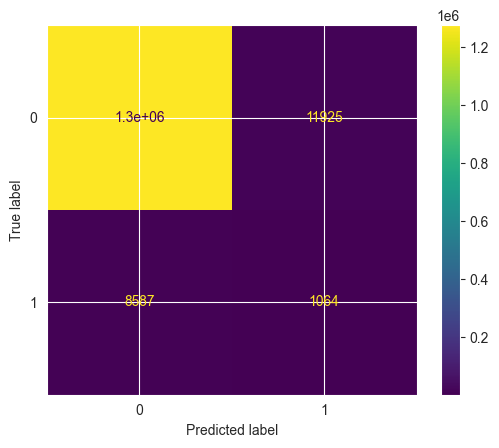

In [79]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Afficher les métriques clés (Précision, Rappel, F1-Score)
print(classification_report(df_sav['is_fraud'], df_final['predictions']))

# Visualiser la matrice de confusion de manière pro
ConfusionMatrixDisplay.from_predictions(df_sav['is_fraud'], df_final['predictions'])

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1289169
           1       0.08      0.11      0.09      9651

    accuracy                           0.98   1298820
   macro avg       0.54      0.55      0.54   1298820
weighted avg       0.99      0.98      0.99   1298820


<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1dfaa252190>
<Figure size 640x480 with 2 Axes>